### **Experiments for N-dim convex optimization problem**

We have trained more adaptive learning rate (LR) models for Gradient Descent models to be used in higher dimensions: **[5, 10, 100, 800]**

800 is the maximum value because we need the measurement to align with the number of parameters in the MNIST problem

In [1]:
import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt

import src.gymnasium_envs.convex_optimization_env
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from src.optimization.convex_function import ConvexFunction
from src.optimization.optimization_methods import gradient_descent_optimizer, adam_optimizer

seed = 0

available_dims = [5, 10, 100, 800]

Lets define a function that plots comparison of adaptive algorithm with standard methods

In [2]:
def plot_algorithm_comparasion(dim : int, seed : int):
    # Initialize environment
    env = make_vec_env(
        "convex_optimization_env/ConvexOptimization-v0",
        n_envs=1,
        seed=seed,
        env_kwargs={
            "render_mode": "ansi",
            "in_features": dim
        }
    )
    env = VecNormalize.load(f"../models/{dim}d_convex_optimization_vec_normalize_stats.pkl", env)
    env.training = False
    env.norm_reward = False 

    # Load model
    model = PPO.load(f"../models/{dim}d_convex_optimization", env=env, seed=seed)

    obs = env.reset()
    x0 = env.envs[0].unwrapped.get_x_start()

    # Using adaptive algorithm
    done = False

    rl_gd_info = []

    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, info = env.step(action)
        rl_gd_info.append(info)
        done = terminated
    
    # Using standart algorithms
    function1 = ConvexFunction(in_features=dim, random_state=seed)

    gd_info = []
    adam_info = []

    gradient_descent_optimizer(function1, x0=x0, opt_info=gd_info)
    adam_optimizer(function1, x0=x0, opt_info=adam_info)

    #Plot result 
    gd_it, gd_val = zip(*[(item['iteration'], item['function_value']) for item in gd_info])
    adam_it, adam_val = zip(*[(item['iteration'], item['function_value']) for item in adam_info])
    rl_gd_it, rl_gd_val = zip(*[(item[0]['iteration'], item[0]['function_value']) for item in rl_gd_info[:-2]])

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    sns.lineplot(x=gd_it, y=gd_val, label='Gradient Descent')
    sns.lineplot(x=adam_it, y=adam_val, label='ADAM')
    sns.lineplot(x=rl_gd_it, y=rl_gd_val, label=f'GD with adaptive LR (dim={dim})')

    plt.title(f'Convex optimization task (n_features={dim}): ADAM vs GD vs GD with adaptive LR')
    plt.xlabel('Iteration')
    plt.ylabel('Function Value')
    plt.legend()
    plt.show()

Now we'll plot comparasion on higher dimensions

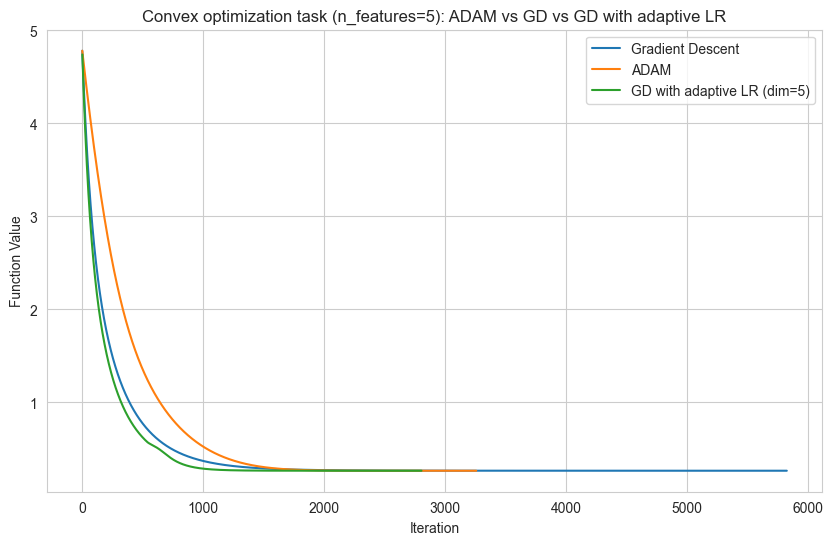

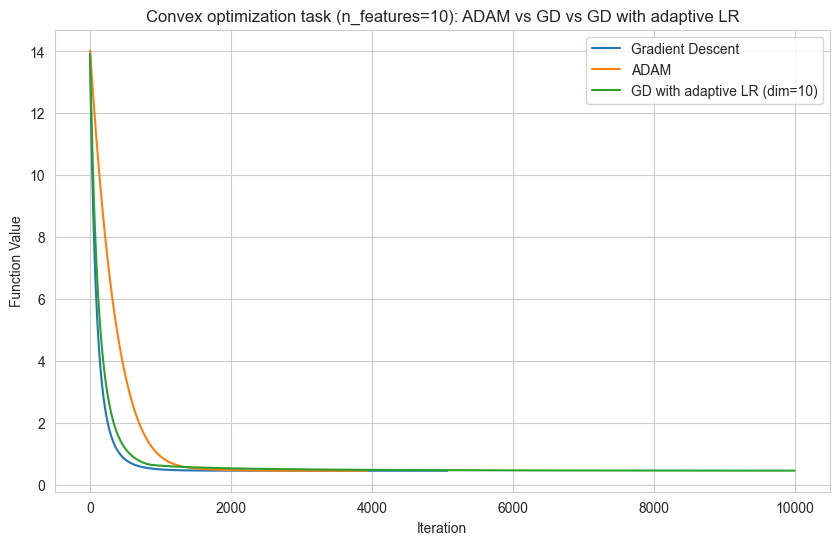

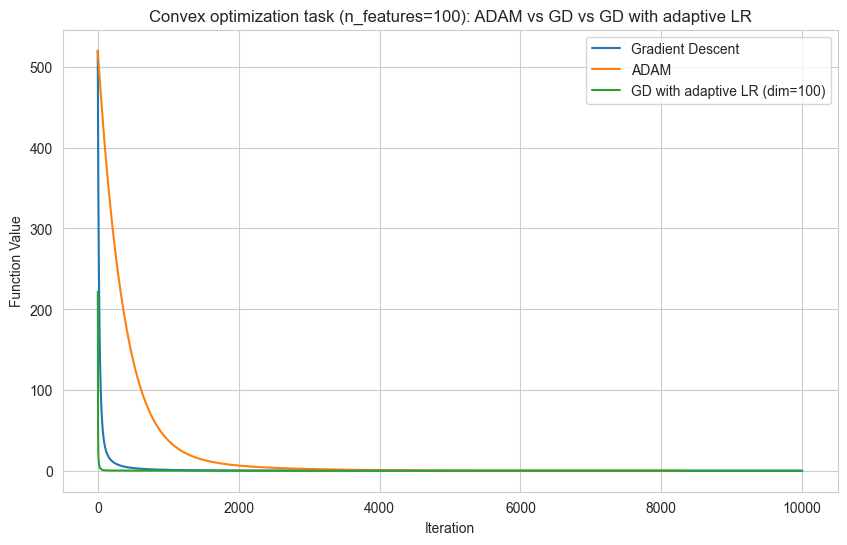

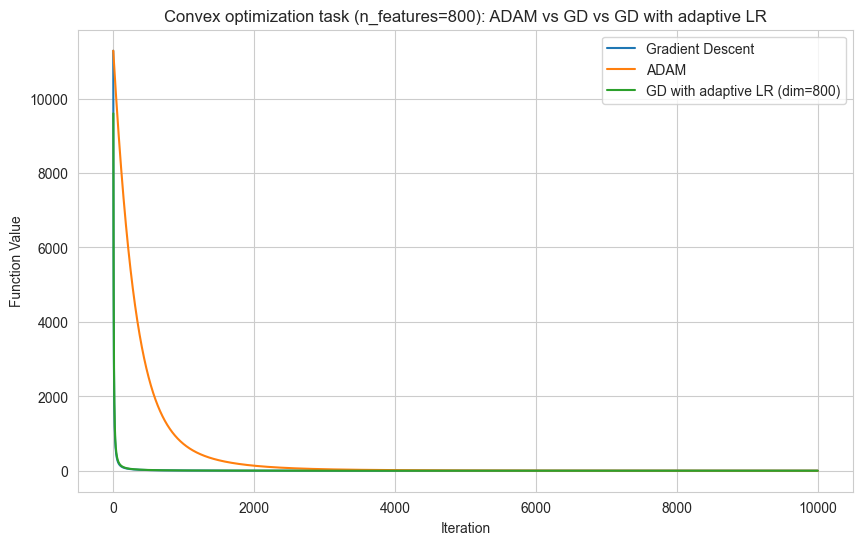

In [3]:
for dim in available_dims:
    plot_algorithm_comparasion(dim, seed=seed)